In [7]:
import numpy as np
import pandas as pd
df= pd.read_csv("../../data/IMDb_Top_700_Movies_2026.csv")
fulldf= pd.read_csv("../../data/IMDb_Top_700_Movies_2026.csv")

In [8]:
df.loc[fulldf["Year"] < 1999, "Year"] = np.nan

In [9]:
df

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,NaN,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,NaN,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008.0,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003.0,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,NaN,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195
...,...,...,...,...,...,...,...,...,...,...
695,696,The Count of Monte Cristo,2002.0,Action|Adventure|Drama,Kevin Reynolds,Jim Caviezel|Guy Pearce|Christopher Adamson,LV|DK,7.7,161156,131
696,697,The Cove,2009.0,Biography|Crime|Documentary,Louie Psihoyos,NaN,DK|PT,8.4,52761,92
697,698,The Wages of Fear,NaN,Adventure|Drama|Thriller,Henri-Georges Clouzot,Yves Montand|Charles Vanel|Peter van Eyck,DK|AT,8.1,74075,156
698,699,Good Bye Lenin!,2003.0,Comedy|Drama|Romance,Wolfgang Becker,Daniel Brühl|Katrin Sass|Chulpan Khamatova,PT|ZA,7.7,160485,121


In [10]:


def impute_missing(data_cruda, strategy='mean', columns=None):
    
    if columns:
    	data_cruda = data_cruda[columns]
    data = data_cruda.select_dtypes(include="number")
    if strategy == "mean":
        count_dictionary = {}
        dictionary = {}
        
        for k in data.index:
            for c,i in data.loc[k].items():
                if pd.notna(i):
                    dictionary[c]=dictionary.get(c,0) + i
                    count_dictionary[c]= count_dictionary.get(c,0)+1
        replacement = {}
        for i in count_dictionary.keys():
            replacement[i] = np.floor(dictionary[i]/count_dictionary[i])
    elif strategy == "median":
        replacement={}
        for i in data.columns:
            
            sorted_data = data[i].dropna()
            sorted_data = sorted_data.sort_values()
            replacement[i]=sorted_data[sorted_data.index[-1]//2]
    elif strategy == "mode":
        valuecounts =data.dropna()
        replacement={}
        for i in valuecounts.columns:
            replacement[i]=valuecounts[i].value_counts().idxmax()
        
    return data.fillna(replacement)
    
impute_missing(df, "mode")

,Rank,Year,IMDb Rating,Votes,Runtime (mins)
0,1,2014.0,9.3,3219532,142
1,2,2014.0,9.2,2244476,175
2,3,2008.0,9.1,3205233,152
3,4,2003.0,9.0,2181911,201
4,5,2014.0,9.0,1595992,195
...,...,...,...,...,...
695,696,2002.0,7.7,161156,131
696,697,2009.0,8.4,52761,92
697,698,2014.0,8.1,74075,156
698,699,2003.0,7.7,160485,121


In [11]:
df

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,NaN,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,NaN,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008.0,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003.0,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,NaN,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195
...,...,...,...,...,...,...,...,...,...,...
695,696,The Count of Monte Cristo,2002.0,Action|Adventure|Drama,Kevin Reynolds,Jim Caviezel|Guy Pearce|Christopher Adamson,LV|DK,7.7,161156,131
696,697,The Cove,2009.0,Biography|Crime|Documentary,Louie Psihoyos,NaN,DK|PT,8.4,52761,92
697,698,The Wages of Fear,NaN,Adventure|Drama|Thriller,Henri-Georges Clouzot,Yves Montand|Charles Vanel|Peter van Eyck,DK|AT,8.1,74075,156
698,699,Good Bye Lenin!,2003.0,Comedy|Drama|Romance,Wolfgang Becker,Daniel Brühl|Katrin Sass|Chulpan Khamatova,PT|ZA,7.7,160485,121


In [12]:
df.isna().sum()

Rank                0
Title               0
Year              262
Genre(s)            0
Director            0
Main Actor(s)      10
Country             0
IMDb Rating         0
Votes               0
Runtime (mins)      0
dtype: int64

In [13]:
df[df.index == 1]

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
1,2,The Godfather,NaN,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175


In [22]:
def detect_outliers(data, method='iqr', threshold=1.5):
    solution = {}
    data = data.select_dtypes(include="number")
    if method == "iqr":
        for i in data.columns:
            lower = np.percentile(data[i], 25)
            upper = np.percentile(data[i], 75)
            iqr = upper - lower
        
            lower = lower - (threshold * iqr)
            upper = upper + (threshold * iqr)
            solution[i]=(data[i] >= upper) | (data[i] <= lower)
    elif method == "zscore":
        
        count_dictionary = {}
        dictionary = {}
        means={}
        
        for k in data.index:
            for c,i in data.loc[k].items():
                if pd.notna(i):
                    dictionary[c]=dictionary.get(c,0) + i
                    count_dictionary[c]= count_dictionary.get(c,0)+1
        stds={}
        
        for z in dictionary.keys():
            
            means[z]=dictionary[z]/count_dictionary[z]
            stds[z]=sum((data[z].dropna() - means[z])**2/count_dictionary[z])
            
            if stds[z] != 0:
                solution[z] = threshold<abs((data[z]-means[z])/stds[z])
            else:
                solution[z] = data[z][1 == 2]
    return pd.DataFrame(solution)
    
    

,Rank,Year,IMDb Rating,Votes,Runtime (mins)
0,False,False,True,False,False
1,False,False,True,False,False
2,False,False,True,False,False
3,False,False,True,False,False
4,False,False,True,False,False
...,...,...,...,...,...
695,False,False,True,False,False
696,False,False,True,False,False
697,False,False,False,False,False
698,False,False,True,False,False


In [53]:
def handle_outliers(data, method='iqr',action="trim", threshold=1.5):
    solution = {}
    data = data.select_dtypes(include="number")
    if method == "iqr":
        for i in data.columns:
            lower = np.percentile(data[i], 25)
            upper = np.percentile(data[i], 75)
            iqr = upper - lower
        
            lower = lower - (threshold * iqr)
            upper = upper + (threshold * iqr)
            solution[i]=(data[i] >= upper) | (data[i] <= lower)
    elif method == "zscore":
        
        count_dictionary = {}
        dictionary = {}
        means={}
        
        for k in data.index:
            for c,i in data.loc[k].items():
                if pd.notna(i):
                    dictionary[c]=dictionary.get(c,0) + i
                    count_dictionary[c]= count_dictionary.get(c,0)+1
        stds={}
        
        for z in dictionary.keys():
            
            means[z]=dictionary[z]/count_dictionary[z]
            stds[z]=sum((data[z].dropna() - means[z])**2/count_dictionary[z])
            
            if stds[z] != 0:
                solution[z] = threshold<abs((data[z]-means[z])/stds[z])
            else:
                solution[z] = data[z][1 == 2]
    outliners = pd.DataFrame(solution)
    if action == "trim":
        for c in outliners.index:
            if outliners.loc[c].any():
                data.drop(c, inplace=True)
        data.reset_index(drop=True,inplace=True)
    else:
        replacements={}
        for i in data.columns:
            lower = np.percentile(data[i], 25)
            upper = np.percentile(data[i], 75)
            iqr = upper - lower
        
            lower = lower - (threshold * iqr)
            upper = upper + (threshold * iqr)
            replacements[i] = (lower,upper)
        for column in data.columns:
            lower = replacements[column][0]
            upper = replacements[column][1]

            data[column] = data[column].clip(lower=lower,upper=upper)
        
    return data


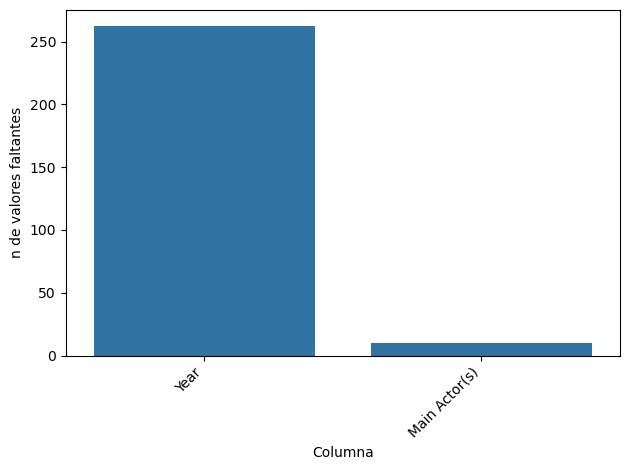

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_missing(data):
    count_dictionary = {}
    
    for k in data.index:
        for c,i in data.loc[k].items():
            if not pd.notna(i):
                count_dictionary[c]= count_dictionary.get(c,0)+1
    sns.barplot(
    x=count_dictionary.keys(),
    y=count_dictionary.values()
)
    
    plt.xlabel("Columna")
    plt.ylabel("n de valores faltantes")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()
plot_missing(df)